###YOLO v5 Object Car Detection

### Libraries

In [1]:
import os, time, random
import numpy as np
import pandas as pd
import cv2, torch
from tqdm.auto import tqdm
import shutil as sh

from IPython.display import Image, clear_output
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
%%time

!git clone https://github.com/ultralytics/yolov5
!pip install -U pycocotools
!pip install -qr yolov5/requirements.txt
!cp yolov5/requirements.txt ./

Cloning into 'yolov5'...
remote: Enumerating objects: 17413, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 17413 (delta 64), reused 22 (delta 22), pack-reused 17327 (from 4)
Receiving objects: 100% (17413/17413), 16.30 MiB | 29.49 MiB/s, done.
Resolving deltas: 100% (11935/11935), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 107.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━

In [5]:
!pip install kaggle

In [6]:
!mkdir -p ~/.kaggle

In [8]:
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [9]:
!kaggle datasets download -d sshikamaru/car-object-detection

Dataset URL: https://www.kaggle.com/datasets/sshikamaru/car-object-detection
License(s): other


In [10]:
!unzip car-object-detection.zip

Archive:  car-object-detection.zip
  inflating: data/sample_submission.csv  
  inflating: data/testing_images/vid_5_25100.jpg  
  inflating: data/testing_images/vid_5_25120.jpg  
  inflating: data/testing_images/vid_5_25140.jpg  
  inflating: data/testing_images/vid_5_25160.jpg  
  inflating: data/testing_images/vid_5_25180.jpg  
  inflating: data/testing_images/vid_5_25200.jpg  
  inflating: data/testing_images/vid_5_25220.jpg  
  inflating: data/testing_images/vid_5_25240.jpg  
  inflating: data/testing_images/vid_5_25260.jpg  
  inflating: data/testing_images/vid_5_26320.jpg  
  inflating: data/testing_images/vid_5_26400.jpg  
  inflating: data/testing_images/vid_5_26420.jpg  
  inflating: data/testing_images/vid_5_26560.jpg  
  inflating: data/testing_images/vid_5_26580.jpg  
  inflating: data/testing_images/vid_5_26600.jpg  
  inflating: data/testing_images/vid_5_26620.jpg  
  inflating: data/testing_images/vid_5_26640.jpg  
  inflating: data/testing_images/vid_5_26660.jpg  
  inf

## Loading Data 📝 / Preprocessing ⚙️

In [17]:
img_h, img_w, num_channels = (380, 676, 3)
df = pd.read_csv('/content/data/train_solution_bounding_boxes (1).csv')
df.rename(columns={'image':'image_id'}, inplace=True)
df['image_id'] = df['image_id'].apply(lambda x: x.split('.')[0])
df['x_center'] = (df['xmin'] + df['xmax'])/2
df['y_center'] = (df['ymin'] + df['ymax'])/2
df['w'] = df['xmax'] - df['xmin']
df['h'] = df['ymax'] - df['ymin']
df['classes'] = 0
df['x_center'] = df['x_center']/img_w
df['w'] = df['w']/img_w
df['y_center'] = df['y_center']/img_h
df['h'] = df['h']/img_h
df.head()

,image_id,xmin,ymin,xmax,ymax,x_center,y_center,w,h,classes
0,vid_4_1000,281.259045,187.035071,327.727931,223.225547,0.450434,0.539817,0.068741,0.095238,0
1,vid_4_10000,15.163531,187.035071,120.329957,236.430180,0.100217,0.557191,0.155572,0.129987,0
2,vid_4_10040,239.192475,176.764801,361.968162,236.430180,0.444645,0.543678,0.181621,0.157014,0
3,vid_4_10020,496.483358,172.363256,630.020260,231.539575,0.833213,0.531451,0.197540,0.155727,0
4,vid_4_10060,16.630970,186.546010,132.558611,238.386422,0.110347,0.559122,0.171491,0.136422,0


In [14]:
index = list(set(df.image_id))
image = random.choice(index)
print(f"Selected image ID from dataframe: {image}")


img = cv2.imread(f'/content/data/training_images/{image}.jpg')


if img is not None:
    print(f"Image shape: {img.shape}")
else:
    print(f"Failed to load image: {image}")


    import os
    if os.path.exists(f'/content/data/training_images/{image}.jpg'):
        print("File exists but couldn't be read - might be corrupted")
    else:
        print("File doesn't exist at the specified path")


        if os.path.exists('/content/data/training_images'):
            files = os.listdir('/content/data/training_images')
            print(f"Files in directory (showing first 5): {files[:5]}")

Selected image ID from dataframe: vid_4_2420
Image shape: (380, 676, 3)


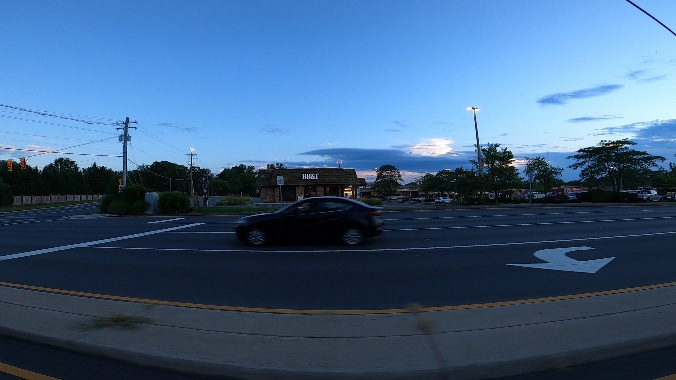

In [15]:
image = random.choice(index)
Image(filename=f'/content/data/training_images/{image}.jpg',width=600)

## Training

In [16]:
source = 'training_images'
if True:
    for fold in [0]:
        val_index = index[len(index)*fold//5:len(index)*(fold+1)//5]
        for name,mini in tqdm(df.groupby('image_id')):
            if name in val_index:
                path2save = 'val2017/'
            else:
                path2save = 'train2017/'
            if not os.path.exists('/tmp/convertor/fold{}/labels/'.format(fold)+path2save):
                os.makedirs('/tmp/convertor/fold{}/labels/'.format(fold)+path2save)
            with open('/tmp/convertor/fold{}/labels/'.format(fold)+path2save+name+".txt", 'w+') as f:
                row = mini[['classes','x_center','y_center','w','h']].astype(float).values
                row = row.astype(str)
                for j in range(len(row)):
                    text = ' '.join(row[j])
                    f.write(text)
                    f.write("\n")
            if not os.path.exists('/tmp/convertor/fold{}/images/{}'.format(fold,path2save)):
                os.makedirs('/tmp/convertor/fold{}/images/{}'.format(fold,path2save))
            sh.copy("/content/data/{}/{}.jpg".format(source,name),'/tmp/convertor/fold{}/images/{}/{}.jpg'.format(fold,path2save,name))

  0%|          | 0/355 [00:00<?, ?it/s]

In [26]:
import os
import pandas as pd
import shutil


csv_path = '/content/data/train_solution_bounding_boxes (1).csv'


images_dir = '/content/data/training_images'
labels_dir = '/content/data/training_images/labels'


os.makedirs(labels_dir, exist_ok=True)


df = pd.read_csv(csv_path)


grouped = df.groupby('image')


for image_name, annotations in grouped:

    image_base = os.path.splitext(image_name)[0]
    label_path = os.path.join(labels_dir, f"{image_base}.txt")


    with open(label_path, 'w') as f:

        for _, row in annotations.iterrows():

            xmin = float(row['xmin'])
            ymin = float(row['ymin'])
            xmax = float(row['xmax'])
            ymax = float(row['ymax'])


            img_width = xmax - xmin
            img_height = ymax - ymin


            from PIL import Image
            img_path = os.path.join(images_dir, image_name)
            if os.path.exists(img_path):
                with Image.open(img_path) as img:
                    img_width, img_height = img.size


            x_center = (xmin + xmax) / (2 * img_width)
            y_center = (ymin + ymax) / (2 * img_height)
            width = (xmax - xmin) / img_width
            height = (ymax - ymin) / img_height


            class_id = 0


            f.write(f"{class_id} {x_center} {y_center} {width} {height}\n")

print(f"Converted {len(grouped)} images' annotations to YOLO format")

Converted 355 images' annotations to YOLO format


In [48]:

import glob
import os


label_files = glob.glob('/content/data/labels/**/*.txt', recursive=True)
print(f"Found {len(label_files)} label files")
if label_files:
    print("Sample label files:")
    for file in label_files[:5]:
        print(f"  - {file}")

        with open(file, 'r') as f:
            print(f"    Content: {f.read().strip()}")
else:
    print("No label files found! This is the root issue.")

Found 355 label files
Sample label files:
  - /content/data/labels/vid_4_9760.txt
    Content: 0 0.029133284778106505 0.5633500647368421 0.05826656955621301 0.0854922278947368
0 0.5273124545118343 0.5529873703947369 0.29424617618343196 0.16839378236842104
0 0.7738528769230769 0.5270806346052631 0.15367807721893495 0.11917098447368421
  - /content/data/labels/vid_4_23000.txt
    Content: 0 0.4725036179733727 0.5707046332894736 0.17510853831360945 0.10553410552631576
  - /content/data/labels/vid_4_9740.txt
    Content: 0 0.25819373631656806 0.5594640544736842 0.14639475606508875 0.11139896368421048
  - /content/data/labels/vid_4_23020.txt
    Content: 0 0.1204775687352071 0.5745656371052631 0.15557163531065088 0.09781209789473683
  - /content/data/labels/vid_4_21620.txt
    Content: 0 0.8035455860946746 0.5616956242105263 0.2481910275147929 0.15444015421052634


In [ ]:

import os
import shutil


os.makedirs('/content/data/labels/training_images', exist_ok=True)
os.makedirs('/content/data/labels/testing_images', exist_ok=True)
print("Directory structure created/verified")

In [49]:

import yaml


car_config = {
    'path': '/content/data',
    'train': 'images/training_images',
    'val': 'images/testing_images',
    'nc': 1,
    'names': ['car'],


    'labels': 'labels'
}


with open('/content/yolov5-config/car_fixed.yaml', 'w') as file:
    yaml.dump(car_config, file, default_flow_style=False)

print("car_fixed.yaml file created successfully!")

car_fixed.yaml file created successfully!


In [50]:

!rm -f /content/data/training_images.cache

In [53]:
!python /content/yolov5/train.py --batch 2 --epochs 1 --data /content/yolov5-config/car.yaml --cfg /content/yolov5/models/yolov5n.yaml

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2025-05-03 08:16:37.426554: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746260197.446538   16423 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746260197.452541   16423 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 3
wandb: You chose "Don't visualize my results"
wandb: WARNING If you're specifying your api key in code, ensure this cod

## Prediction

In [55]:
!python yolov5/detect.py --weights yolov5/yolov5s.pt --img 676 --conf 0.4 --source /content/data/images/testing_images

detect: weights=['yolov5/yolov5s.pt'], source=/content/data/images/testing_images, data=yolov5/data/coco128.yaml, imgsz=[676, 676], conf_thres=0.4, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=yolov5/runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-416-gfe1d4d99 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
WARNING ⚠️ --img-size [676, 676] must be multiple of max stride 32, updating to [704, 704]
image 1/175 /content/data/images/testing_images/vid_5_25100.jpg: 416x704 (no detections), 28.6ms
image 2/175 /content/data/images/testing_images/vid_5_25120.jpg: 416x704 (no detections), 9.7ms
image 3/175 

In [58]:
predicted_files = []
for (dirpath, dirnames, filenames) in os.walk("runs/detect/exp2"):
    predicted_files.extend(filenames)

Found 175 image files in yolov5/runs/detect/exp2
Displaying: yolov5/runs/detect/exp2/vid_5_25120.jpg


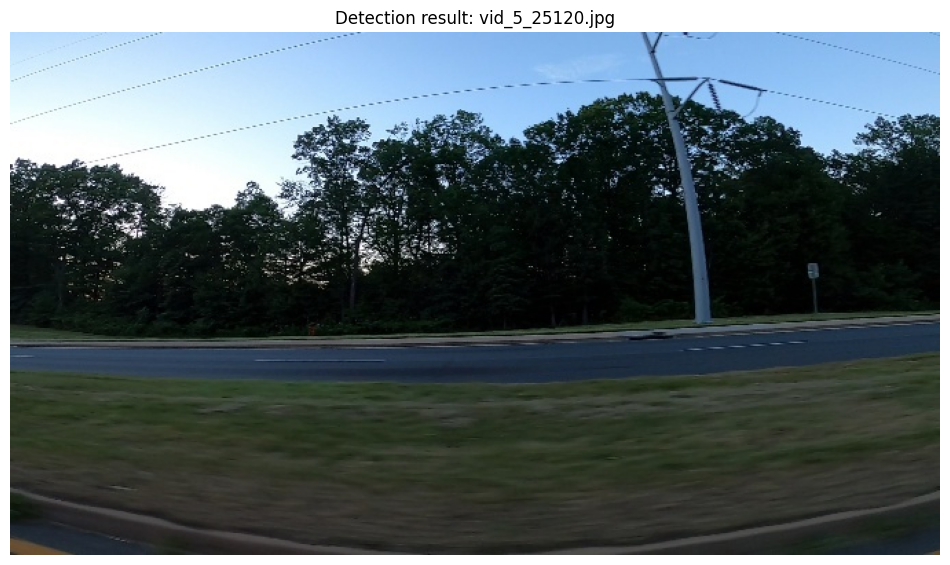

In [60]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image


detect_path = "yolov5/runs/detect/exp2"


if not os.path.exists(detect_path):
    print(f"Directory '{detect_path}' does not exist.")

    alternative_paths = [
        "runs/detect/exp",
        "/content/yolov5/runs/detect/exp",
        "detect/exp",
        "exp"
    ]

    for path in alternative_paths:
        if os.path.exists(path):
            print(f"Found alternative path: {path}")
            detect_path = path
            break
    else:
        print("Could not find detection results directory!")
        print("Current directory:", os.getcwd())
        print("Contents of current directory:", os.listdir("."))


if os.path.exists(detect_path):
    predicted_files = []
    for dirpath, dirnames, filenames in os.walk(detect_path):
        for filename in filenames:

            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                full_path = os.path.join(dirpath, filename)
                predicted_files.append(full_path)

    print(f"Found {len(predicted_files)} image files in {detect_path}")

    if predicted_files:

        random_image = random.choice(predicted_files)
        print(f"Displaying: {random_image}")

        plt.figure(figsize=(12, 10))
        img = Image.open(random_image)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Detection result: {os.path.basename(random_image)}")
        plt.show()
    else:
        print(f"No image files found in {detect_path}")
        print(f"Directory contents: {os.listdir(detect_path)}")

Found 175 image files
Selected file: vid_5_30180.jpg


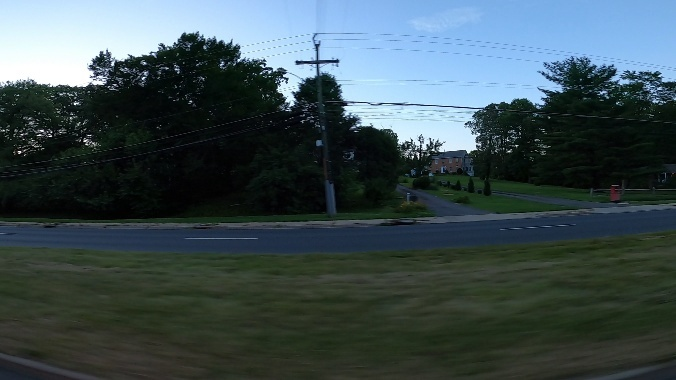

In [63]:

import os
import random
from IPython.display import Image


detect_path = '/content/yolov5/runs/detect/exp2'


if not os.path.exists(detect_path):
    print(f"Directory '{detect_path}' does not exist!")
else:

    predicted_files = []
    for dirpath, dirnames, filenames in os.walk(detect_path):
        for filename in filenames:

            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                predicted_files.append(filename)

    print(f"Found {len(predicted_files)} image files")

    if predicted_files:

        selected_file = random.choice(predicted_files)
        print(f"Selected file: {selected_file}")


        display(Image(filename=f'{detect_path}/{selected_file}'))
    else:
        print(f"No image files found in {detect_path}")
        print(f"Directory contents: {os.listdir(detect_path)}")

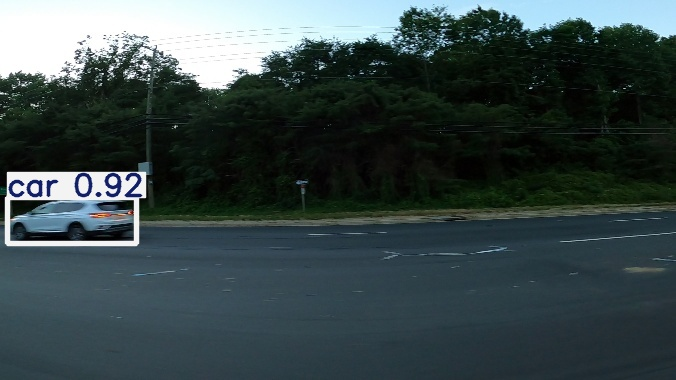

In [69]:
Image(filename=f'/content/yolov5/runs/detect/exp2/{random.choice(predicted_files)}')

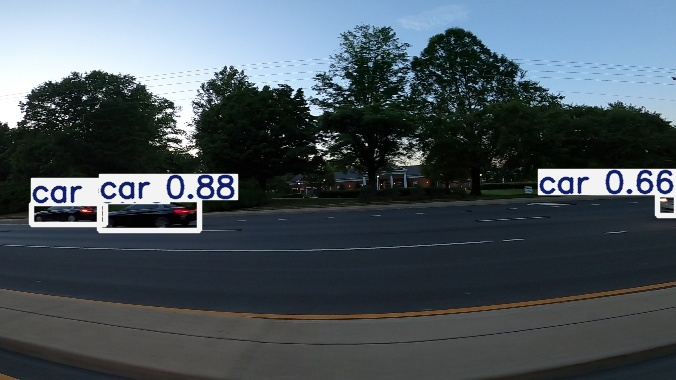

In [70]:
Image(filename=f'/content/yolov5/runs/detect/exp2/{random.choice(predicted_files)}')

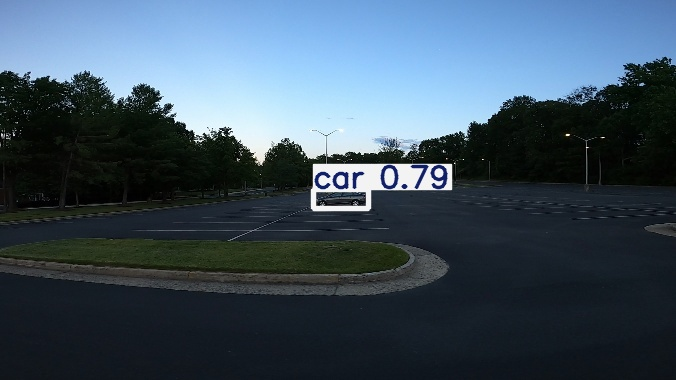

In [71]:
Image(filename=f'/content/yolov5/runs/detect/exp2/{random.choice(predicted_files)}')

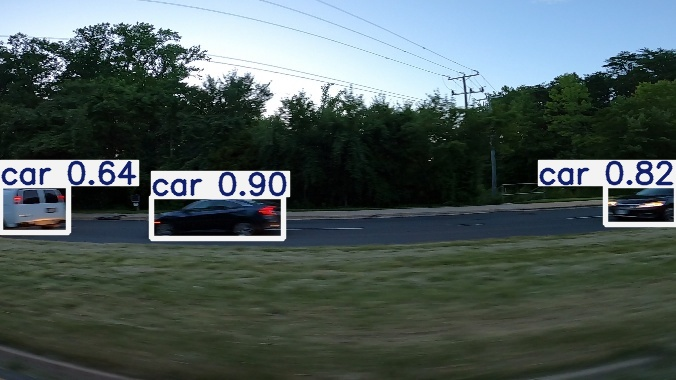

In [77]:
Image(filename=f'/content/yolov5/runs/detect/exp2/{random.choice(predicted_files)}')

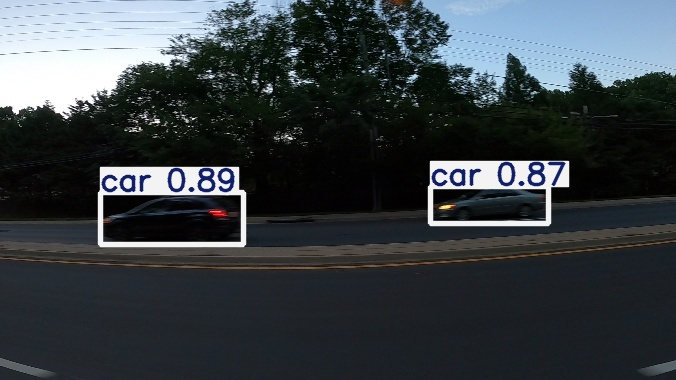

In [78]:
Image(filename=f'/content/yolov5/runs/detect/exp2/{random.choice(predicted_files)}')

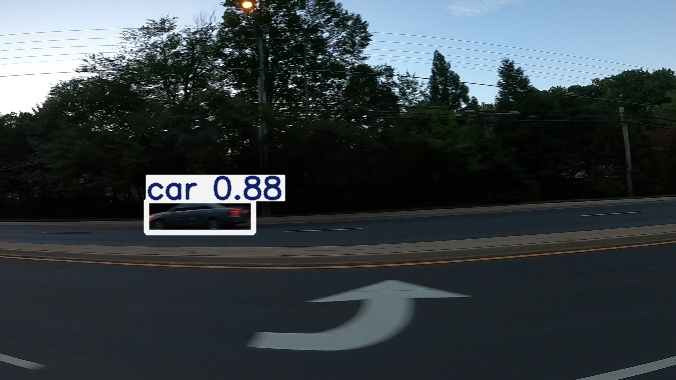

In [80]:
Image(filename=f'/content/yolov5/runs/detect/exp2/{random.choice(predicted_files)}')